# Es Freschers 

In [1]:
#librerie
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from qutip import *
from IPython.display import Image, display, Math

In [2]:
#funzione per plottare in LaTex delle matrici
def array_to_latex(array, real = False, array_name = None):
    array = array.real if real else array
    matrix = ''
    for row in array:
        try:
            for number in row:
                matrix += f'{number}&'
        except TypeError:
            matrix += f'{row}&'
        matrix = matrix[:-1] + r'\\'
    if array_name != None:
        display(Math(array_name+r' = \begin{bmatrix}'+matrix+r'\end{bmatrix}'))
    else:
        display(Math(r'\begin{bmatrix}'+matrix+r'\end{bmatrix}'))

## Excitonic Dimer
We will use a excionic dimer as model system; each monomer is a Two_Level_system (TLS), with both the ground state $ \ket{g} = 0.0 Ev $ and an excited state with differente energies, in particular : $ \ket{e_1} = 1.46 Ev $ and $ \ket{e_2} = 1.55 Ev $. We can now define the system's Hamiltonian in the $ \textbf{Site Basis} $ as : $$ H = H_1 + H_2 + H_{int} $$ <center> with: $ H_1 = E_1\ket{e_1}\bra{e_1} $, $ H_2 = E_2\ket{e_2}\bra{e_2} $, $ H_{int} \propto V $ with V the Interction Potential between the two monomers.</center> <br>
To be more precise, specifing the two different Hilbet Spaces : $ H = H_1 \otimes \mathbb{1_2} +  \mathbb{1_1} \otimes H_2 + V (\ket{e_1 g_2}\bra{e_2 g_1} + \ket{e_2 g_1}\bra{e_1 g_2})$ with $ \ket{\psi_2, \psi_1} = \ket{\psi_2} \otimes \ket{\psi_1} $

In [3]:
#Hamiltonian definition
N = 2
#E = 1.5 + np.random.randn(N)*0.1 #inizializzazione casuale dell'energia dei siti
E1 = 1.46
E2 = 1.55
V = 0.1

H = [ [0, 0, 0, 0],    #scritto così per convenzioe QuTip per cui la bas deve essere (|00>, |10>, |01>, |11>)
      [0, E2, V, 0],
      [0, V, E1, 0],
      [0, 0, 0, E1+E2] ]
H_np = np.array(H)
array_to_latex(H_np)

<IPython.core.display.Math object>

It's possibile to focus only on the two excited state and follow their dynamics; in this case we introduce an effective hamiltonian like this:

In [4]:
#Excited state's Hamiltonian 
E1 = 1.46
E2 = 1.55
V = 0.1

H_exc = [ [E1, V],
          [V, E2], ]
H_exc_np = np.array(H_exc)
array_to_latex(H_exc)

<IPython.core.display.Math object>

If we now diagonalize this Hamiltonian we could get the $ \textbf{Exciton basis} $ of the system; in particular the eigenvalue in the exciton basis are : $$ E_\pm = \frac{E_1 + E_2 \pm \sqrt{4V^{2} + \Delta E^{2}}}{2} $$

In [5]:
#Excited state's Hamiltonian diagonalization

#con numpy

w_np, v_np = np.linalg.eigh(H_exc) #w = autovalori, v = autovettori

#check_energy = (E1 + E2 + np.sqrt(4.0*(V**2) + ((E1-E2)**2)))/2
#w, check_energy
#prob = v**2 #quadrato dei coefficienti restituisce probabilità di occupazione dello stato eccitato 1 o 2 
Diag_exc_np = np.diag(w_np)
array_to_latex(Diag_exc_np)

<IPython.core.display.Math object>

In [6]:
#con QuTip
H1 = (E1/2) * tensor(qeye(2) - sigmaz(), qeye(2))
H2 = (E2/2) * tensor(qeye(2), qeye(2) - sigmaz())
H_int = V * (tensor(sigmap(), sigmam()) + tensor(sigmam(), sigmap()))
H_q = (H1 + H2 + H_int)

In [7]:
w, v = H_q.eigenstates()
D_q = Qobj(np.diag(w)) #matrice diagonalizzata
D_q

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.         0.         0.         0.        ]
 [0.         1.39534144 0.         0.        ]
 [0.         0.         1.61465856 0.        ]
 [0.         0.         0.         3.01      ]]

In [8]:
#per la matrice dei soli stati eccitati
H_exc_q =  Qobj(H_exc_np)
w, v = H_exc_q.eigenstates()
D_exc = np.diag(w)
array_to_latex(D_exc)

<IPython.core.display.Math object>

We can build up the evolution operator $ U = \exp(-i\hat{H}dt) $

In [9]:
#with the function expm which act on matrices
dt, t_final = 1e-7, 1e-5
t = np.arange(0,t_final,dt)

def U_np (E1, E2, V, dt):
    H = [ [E1, V],
          [V, E2], ]
    H_np = np.array(H)

    U_np = expm(-1.j * H_np * dt)

    return np.array(U_np)

def U_qtip (E1, E2, V, dt):
    H1 = (E1/2) * tensor(qeye(2) - sigmaz(), qeye(2))
    H2 = (E2/2) * tensor(qeye(2), qeye(2) - sigmaz())
    H_int = V * (tensor(sigmap(), sigmam()) + tensor(sigmam(), sigmap()))
    H_qtip = (H1 + H2 + H_int)

    U_qtip = (-1.j * H_qtip * dt).expm()

    return Qobj(U_qtip)

U = U_qtip (E1, E2, V, dt)



or by diagonalizing the H matrix with $ D = WHW^\dagger $, than calculate the diagonal U matrix which has only diagonal element such $ U_{jj} = e^{-i E_j dt}  $ and corripsonds to the U operator in the exciton basis; then using the eigenvectors W return to the site basis $ U = W^\dagger UW $,

In [10]:
def U_by_diagonaliz (E1, E2, V, dt):
    H = [ [E1, V],
          [V, E2], ]
    H_np = np.array(H)
    w, v = np.linalg.eigh(H)
    D = np.diag(w_np)  # matrice diagonale degli autovalori
    
    U_autovector = v @ np.diag(np.exp(-1.j * w * dt)) @ np.conj(v).T

    return U_autovector

#### Trotter - Suzuki decomposition
Given an Hamiltonian operator composed of the sum of hermitian matrices which doesn't necessarily commute $ \hat{H} = \sum_{\alpha}^{A} {\hat{H_\alpha}} $ we can approximate the unitary evolutio operator such as : $$ e^{-iHt} = \lim_{n \to \infty} \left( \prod_{\alpha = 1}^{A} {e^{-iH_\alpha \frac{t}{n}}} \right) + \mathcal{O} \left( A^2 \frac{t^2}{n} \right) $$
or 
$$ e^{-iHt} = \lim_{n \to \infty} \left( \prod_{\alpha = 1}^{A} {e^{-iH_\alpha \frac{t}{n}}} \right) + \mathcal{O} \left( A^2 tdt \right)$$ 
where $ dt = \frac{t}{n} $ <br>
So in our case we can rewrite the U opperator as: $$ U \approx e^{-iV\sigma_xdt} e^{-i\frac{E_1 - E_2}{2}\sigma_zdt} $$

In [11]:
def U_trotter(V, E1, E2, dt):
    U_x = expm(- 1.j * V * sigmax().full() * dt)
    U_z = expm(- 1.j * (E1-E2)/2 * sigmaz().full() * dt)
    U_trotter = U_x @ U_z
    return Qobj(U_trotter)

U = U_trotter(V, E1, E2, dt)

Let's create a function whic allows us to choose in different way to calculate, define and apprimate de U operator

In [12]:
def evolution_operator(E1, E2, V, dt, backend='qutip', method='expm'):
    if method == 'expm':
        if backend == 'numpy':
            H = np.array([[E1, V],
                          [V, E2]])
            return expm(-1.j * H * dt)
        elif backend == 'qutip':
            H1 = (E1/2) * tensor(qeye(2) - sigmaz(), qeye(2))
            H2 = (E2/2) * tensor(qeye(2), qeye(2) - sigmaz())
            H_int = V * (tensor(sigmap(), sigmam()) + tensor(sigmam(), sigmap()))
            H_qtip = H1 + H2 + H_int
            return (-1.j * H_qtip * dt).expm()
    elif method == 'diagonalization':
        H = np.array([[E1, V],
                      [V, E2]])
        w, v = np.linalg.eigh(H)
        return v @ np.diag(np.exp(-1.j * w * dt)) @ np.conj(v).T
    elif method == 'trotter':
        U_x = expm(-1.j * V * np.array(sigmax().full()) * dt)
        U_z = expm(-1.j * (E1 - E2)/2 * np.array(sigmaz().full()) * dt)
        U = U_x @ U_z
        if backend == 'qutip':
            return Qobj(U)
        else:
            return U
    else:
        raise ValueError("method must be 'expm', 'diagonalization' or 'trotter'")


To create an array in which we calculate U for evry time step

In [13]:
def evolution_sequence(c, dt, t_final):
    n_steps = int(np.ceil(t_final / dt))
    U_list = []
    for _ in range(n_steps):
        U = evolution_operator(E1, E2, V, dt, backend='qutip', method='expm') 
        U_list.append(U)
    return U_list


#### Density Matrix formalism
The most general description of a system's quantum state it's given by its density matrix : $$ \rho (t) = \sum_{k} {p_k \ket{\psi_k (t) } \bra{\psi_k (t)}} $$ 
The Unitary evolution of the density matrix is given by the Lioville - Von Neumann equation: $$ \frac{d}{dt} \rho (t) = -\frac{i}{\hbar} \left[ \hat{H}, \rho (t) \right] $$ 
Let's try to evolve our initial $ \rho $ and visualize the evolution on the Bloch Sphere (remember that $ \mathbf{r}_{bloch} = \left( < \sigma_x (t) >, < \sigma_y (t) >, < \sigma_z (t) >  \right) $)

In [14]:
H = np.array([[0, 0],
              [0, 1]])
rho = np.array([[1, 0.6],
                [0.6, 1]])/2
dt = 0.5; t_list = np.arange(0, 10 + dt, dt)

result = mesolve(Qobj(H), #risolve Master Equation ma in questo caso non sto definendo nessun operatore di Lindblad
                 Qobj(rho) if Qobj(rho).isherm else False,
                 t_list,
                 e_ops=[sigmax(), sigmay(), sigmaz()])  #calcola in modo esplicito il valore di aspettazione di quei tre operatori risolvendo la ME di LVN in questo caso e calcolando quindi <Oi(t)> = Tr [p(t)Oi] 

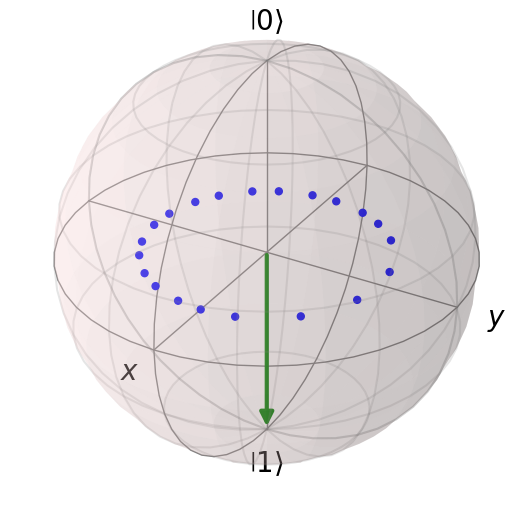

In [15]:
import imageio.v2 as imageio
from os import listdir
from os.path import isfile, join
import shutil
sphere = Bloch()
sx, sy, sz = result.expect[0], result.expect[1], result.expect[2]  #i risulatti del calcolo (valori di apettazione) sono contenuti in result.expect per  ogni tempo t di t_list
sphere.add_points([sx, sy, sz]); sphere.add_vectors([0., 0., -1.])
sphere.show()

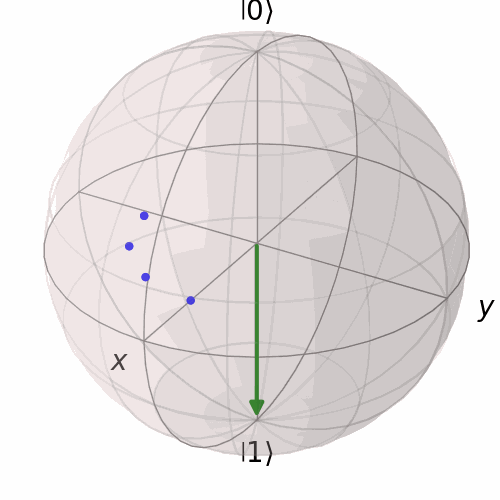

In [16]:
V = 0
sphere = Bloch()
for i in range(len(sx)):
    sphere.clear()
    for j in range(i+1):
        sphere.add_points([sx[j], sy[j], sz[j]], alpha=np.exp((j-i)/15))
    sphere.add_vectors([(0., 0.,-1.)])
    sphere.point_color ='b'; sphere.point_marker = 'o'; sphere.point_size = [25]
    sphere.make_sphere()
    sphere.save(name='temp_site_bloch/eig_bloch_{}.png'.format(str(i).zfill(len(str(len(sx))))), dirc='temp_site_bloch')

filenames = [join('temp_site_bloch', filename) for filename in listdir('temp_site_bloch') if isfile(join('temp_site_bloch', filename))]
with imageio.get_writer('Images/movie_site_bloch.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
shutil.rmtree('temp_site_bloch')

Image(filename="Images/movie_site_bloch.gif")

#### Lindbald Equation
A general density matrix Master Eqution has the form : $$ \frac{d}{dt} \rho (t) = -\frac{i}{\hbar} \left[ \hat{H}, \rho (t) \right] + \mathcal{D} \left[ \rho (t) \right] $$
The Lindbald Equation is a linear and Markovian QME deriving from an axiomatic approach: $$ \frac{d}{dt} \rho (t) = -\frac{i}{\hbar} \left[ \hat{H}, \rho (t) \right] + \sum_{k}^{N^2} {\gamma_k \left( \mathcal{L}_k \rho (t) \mathcal{L}_k^\dagger - \frac{1}{2} \left[ \mathcal{L}_k^\dagger \mathcal{L}_k, \rho (t) \right]_+ \right) } $$
It's possible to move to the so called Lindbald space wher the density matrix becomes a vector and the Lindblad super-operator can be rwerite to act on $ \rho $ vector. This operatio is called Vectorization/Choi-Jamiolkowski isomorphism and gives: $$ \frac{d}{dt} \text{vec} \left\{ \rho (t) \right\} = \mathcal{L} \left\{ \rho (t) \right\} $$ with the Liovillian super-operator : $$ \mathcal{L} = -\frac{i}{\hbar} (I \otimes H - H^T \otimes I ) + \sum_{k} \gamma_{k} \left( L_{k}^{*} \otimes L_{k} - \frac{1}{2} I \otimes L_{k}^{\dagger} L_{k} - \frac{1}{2} (L_{k}^{\dagger}L_{k})^{T} \otimes I \right) $$
and 
$$ \rho(t) = \begin{bmatrix}a & b \\ c & d \\\end{bmatrix} \qquad \text{vec} \{ \rho(t) \} = \begin{bmatrix} a \\ b \\ c \\ d \end{bmatrix} $$
Let's define now the Liovillian super-operator in the Lioville space : 

In [4]:
 def Liouvillian(H: np.ndarray,
                gamma_k: list,
                L_k: list):
    I = np.eye(H.shape[0])  #creo matrice identità delle diemnsioni adatte
    super_L = -1.j * (np.kron(I, H) - np.kron(H.T, I))  #Dissipatore di Lindblad
    for k in range(len(gamma_k)):
        super_L += gamma_k[k] * (np.kron(np.conj(L_k[k]), L_k[k]) - 0.5 * np.kron(I, np.conj(L_k[k]).T @ L_k[k]) - 0.5 * np.kron((np.conj(L_k[k]).T @ L_k[k]).T, I))
    return super_L

And now we can define the evolution due to the Linblad super-operator in the Lioville space, using the unitary evolution operator, based on $ \rho (t) = e^{\mathcal{L}t} \rho (0) $

In [36]:
def Lindblad_evo_U (rho, super_L, t_list):
    dt = t_list[1] - t_list[0]
    rho_vec = np.reshape(rho,(rho.size))   #data p matrice la trasforma in vettore
    rho_vec_list = np.zeros((rho.size, len(t_list)), dtype=complex)
    rho_vec_list[:,0] = rho_vec   #inizializzo l'array di evoluzione con il vettore di p(t0)
    
    super_U = expm(super_L * dt)   #definisco il super-operatore di evoluzione temporale
    
    for i in range(1,len(t_list)):
        rho_vec_list[:,i] = super_U @ rho_vec_list[:,i-1]
    return rho_vec_list

The stucture of the output rho_vec_list is :

$$ \rho_{\text{vec\_list}} =
\begin{pmatrix}
\rho_{00}(t_0) & \rho_{00}(t_1) & \dots & \rho_{00}(t_9) \\
\rho_{01}(t_0) & \rho_{01}(t_1) & \dots & \rho_{01}(t_9) \\
\rho_{10}(t_0) & \rho_{10}(t_1) & \dots & \rho_{10}(t_9) \\
\rho_{11}(t_0) & \rho_{11}(t_1) & \dots & \rho_{11}(t_9) \\
\end{pmatrix} $$

As we did before we can diagonalize the Linblad super operator and given the eigenvectors and eigenvalue define a diagonal U operator, which can let us evolve the density matrix through time and in the end return in the initial basis using the eigenvectors. <br>
The eigenvectors rappresent different Lioville vector of $ \rho $ and a idipendet ways to evolve the density matrix, which corresponds to a jump operator $ \mathcal{L}_k $; <br>the evolution of a single eigenvector is ruled by $ \mathcal{v}_i (t) = e^{(\lambda_i t)} \mathcal{v}_i (0) $.<br> So for $ \lambda  = 0 $ stationary autovector;  $ \lambda $ is real we have a exponential evolution (raising o lowering); $ \lambda $ is immaginary we have an oscillatory evolution, i.e. a phase <br>
So $ \rho (t) = \sum_i {c_i e^{(\lambda_i t)} \mathcal{v}_i}; \;$ with $ c_i $ coefficiet that depends on sovrappostion of the initial states with the eigenstate $ v_i $ .

In [91]:
def Lindblad_evo_U_diagonal (rho, super_L, t_list):
    dt = t_list[1] - t_list[0]
    rho_vec = np.reshape(rho,(rho.size))   #data p matrice la trasforma in vettore
    rho_vec_list = np.zeros((rho.size, len(t_list)), dtype=complex)
    rho_vec_list[:,0] = rho_vec   #inizializzo l'array di evoluzione con il vettore di p(t0)
    
    W,V = np.linalg.eig(super_L)   #diagonalizzo il Lindbladiano
    super_U_diagonal = np.diag(np.exp(-1.j * W * dt))   #definisco il super-operatore di evoluzione temporale
    super_U = V @ super_U_diagonal @ np.linalg.inv(V)
    
    for i in range(1,len(t_list)):
        rho_vec_list[:,i] = super_U @ rho_vec_list[:,i-1]
    return rho_vec_list, V, W

And we can use QuTip too for solving the Lindblad ME given the specific Jump Operator $ \mathcal{L}_k $, that need to be specified in the Liouvillian function (QuTip is based on numerical integration)

In [92]:
H = np.array([[0, 0],
              [0, 1]])
rho = np.array([[1, 0.6],
                [0.6, 1]])/2
dt = 0.5; t_list = np.arange(0, 10 + dt, dt)

L_k = [sigmam(), sigmap()]

gamma_k = [0.1, 0.0]

def Lindblad_evo_qutip (rho, H, gamma_k, L_k, t_list):

    result = mesolve(            
                 Qobj(H),                                  
                 Qobj(rho), 
                 t_list,
                 c_ops=[np.sqrt(gamma_k[0]) * L_k[0], np.sqrt(gamma_k[1]) * L_k[1]],  #operatori di jump
                 e_ops=[sigmax(), sigmay(), sigmaz()],     #valori di aspettazione 
                 options={"store_states": True} 
                 ) 
  
    return result         

res = Lindblad_evo_qutip(rho, H, gamma_k, L_k, t_list)

#matrice densità ad un certo tempo t = 3*dt
rho_t3 = res.states[3]

#valori di aspettazione
sx = res.expect[0]; sy = res.expect[1]; sz = res.expect[2]

rho_t3

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.43035399+0.j         0.0196875 +0.27762565j]
 [0.0196875 -0.27762565j 0.56964601+0.j        ]]

Let's put all togeter

In [5]:
def Lindblad_evo(rho, H, gamma_k, L_k, t_list, method="U", vectorized=True):
    """
    Evoluzione della matrice densità secondo l'equazione di Lindblad.
    
    method: "U" -> propagatore expm(super_L * dt) (richiede L_k come array NumPy)
            "diagonal" -> diagonalizzazione del super-operatore (richiede L_k come array NumPy)
            "qutip" -> utilizzo di mesolve di QuTiP (richiede L_k come Qobj)
    vectorized: True/False per scegliere il formato dell'output
    
    Output:
            - se vectorized=True → array (N^2, Nt)
            - se vectorized=False → array (Nt, N, N)
       
    """
    N = H.shape[0]
    dt = t_list[1] - t_list[0]
    
    # ===============================
    #   METODI U E DIAGONAL
    # ===============================
    if method in ["U", "diagonal"]:
        # Converte eventuali Qobj in array NumPy
        L_k_num = [L.full() if hasattr(L, "full") else np.array(L) for L in L_k]
        H_num = H.full() if hasattr(H, "full") else np.array(H)
        rho_num = rho.full() if hasattr(rho, "full") else np.array(rho)
        
        # Costruisco il Lindbladian
        super_L = Liouvillian(H_num, gamma_k, L_k_num)
        
        # Stato iniziale vettorializzato
        rho_vec = rho_num.reshape(N*N)
        
        # Array risultato
        rho_vec_list = np.zeros((N*N, len(t_list)), dtype=complex)
        rho_vec_list[:, 0] = rho_vec
        
        # Propagatore temporale
        if method == "U":
            super_U = expm(super_L * dt)
            
            # Evoluzione
            for i in range(1, len(t_list)):
                rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
            
            # Output
            if vectorized:
                return rho_vec_list  # (N^2, Nt)
            else:
                return rho_vec_list.T.reshape(len(t_list), N, N)  # (Nt, N, N)
                
        elif method == "diagonal":
            W, V = np.linalg.eig(super_L)
            # Converto esplicitamente a NumPy array
            W = np.array(W)
            V = np.array(V)
            
            U_diag = np.diag(np.exp(W * dt))
            super_U = V @ U_diag @ np.linalg.inv(V)
            
            # Evoluzione
            for i in range(1, len(t_list)):
                rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
            
            # Output con autovettori e autovalori (sempre NumPy array)
            if vectorized:
                return rho_vec_list, V, W  # (N^2, Nt), (N^2, N^2), (N^2,)
            else:
                return rho_vec_list.T.reshape(len(t_list), N, N), V, W  # (Nt, N, N), (N^2, N^2), (N^2,)
    
    # ===============================
    #   METODO QUTIP
    # ===============================
    elif method == "qutip":
        H_qobj = Qobj(H) if not hasattr(H, "full") else H
        rho_qobj = Qobj(rho) if not hasattr(rho, "full") else rho
        
        # Costruzione dei collapse operators
        c_ops = []
        for g, L in zip(gamma_k, L_k):
            if g != 0:
                L_qobj = L if hasattr(L, "full") else Qobj(L)
                c_ops.append(np.sqrt(g) * L_qobj)
        
        # Risoluzione con mesolve
        result = mesolve(
            H_qobj,
            rho_qobj,
            t_list,
            c_ops=c_ops,
            options={"store_states": True},
        )
        
        # Converto gli stati QuTiP in array NumPy vettorializzati
        rho_vec_list = np.zeros((N*N, len(t_list)), dtype=complex)
        for i, rho_t in enumerate(result.states):
            rho_vec_list[:, i] = rho_t.full().reshape(N*N)
        
        # Output
        if vectorized:
            return rho_vec_list
        else:
            return rho_vec_list.T.reshape(len(t_list), N, N)
    
    else:
        raise ValueError("Scegli 'U', 'diagonal' o 'qutip'.")

In [9]:
#System definition
dt = 0.01; t_list = np.arange(0, 100 + dt, dt)
N = 2 # number of sites
E = 1.5 + np.random.randn(N)*0.1   #random inizialization of the system energies {con energia pari a 1.5 ± numero casuale estratto da distribuzione con media 0 e varianza 0.01}
V = 0.1   # Potenziale di interazione
H = np.array ([ [0, 0, 0, 0],
                [0, E[1], V, 0],
                [0, V, E[0], 0],
                [0, 0, 0, E[1]+E[0]] ] )
#Hamiltonian excitonic
H_exc = np.array ([ [E[1], V],     
                [ V, E[0] ] ] , dtype = complex)

#Density Matrix
rho = np.array ([ [0, 0, 0, 0],
                  [0, 0, 0, 0],
                  [0, 0, 1, 0],
                  [0, 0, 0, 0] ] )

#Jump Oerator
L_1 = tensor(sigmap(), sigmam())
L_2 = tensor(sigmam(), sigmap())

L_k = [L_1.full(), L_2.full()]

#Rates
gamma_1 = 0.1 ; gamma_2 = 0.1 
gamma_k = [gamma_1, gamma_2]

Super_L = Liouvillian(H, gamma_k, L_k)

array_to_latex(H, array_name=r'\mathcal{H}') , array_to_latex(Super_L, array_name=r'\mathcal{L}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

(None, None)

In [10]:
# Evolution with diagonalization of the Lindbaldian operator
rho_list_diag, V, W = Lindblad_evo(rho, H, gamma_k, L_k, t_list, method="diagonal", vectorized=False)

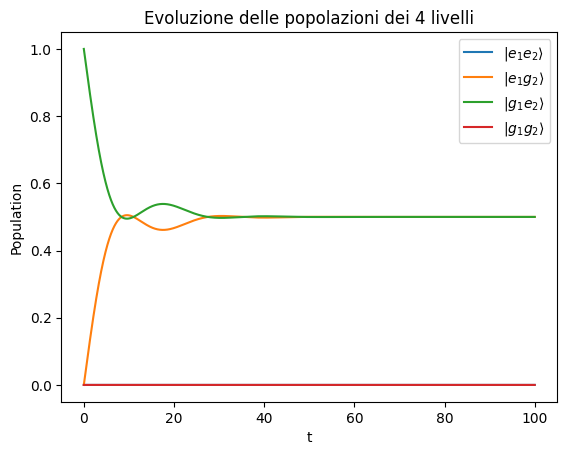

In [11]:
plt.figure()
for i, label in enumerate([r'$|e_1e_2\rangle$', r'$|e_1g_2\rangle$', 
                           r'$|g_1e_2\rangle$', r'$|g_1g_2\rangle$']):
    plt.plot(t_list, np.real(rho_list_diag[:, i, i]), label=label)
    # Nota: [:, i, i] per estrarre l'i-esimo elemento diagonale ad ogni tempo

plt.xlabel('t')
plt.ylabel('Population')
plt.legend()
plt.title('Evoluzione delle popolazioni dei 4 livelli')
plt.show()